# 02 - Baselines and the optimism gap

*This notebook is a thin view: it renders artifacts persisted by the pipeline (`make data features train evaluate figures`). No result is computed here.*

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display

RESULTS = Path.cwd().parent / "results" / "metrics"
FIGURES = Path.cwd().parent / "reports" / "figures"

def load(name):
    with open(RESULTS / f"{name}.json") as fh:
        return json.load(fh)

def fig(name):
    display(Image(str(FIGURES / f"{name}.png"), width=880))


## Tuning (GroupKFold by month, modest Optuna budget)

In [2]:
t = load('stage2_lgbm_tuning')
{k: t[k] for k in ['best_params','best_cv_pr_auc','n_trials','elapsed_s']}

{'best_params': {'num_leaves': 170,
  'learning_rate': 0.03050884446630929,
  'min_child_samples': 25,
  'feature_fraction': 0.7736932106048628,
  'bagging_fraction': 0.7760609974958406,
  'reg_alpha': 0.002827585657311758,
  'reg_lambda': 0.06786479434196534,
  'bagging_freq': 1},
 'best_cv_pr_auc': 0.6256353899769058,
 'n_trials': 12,
 'elapsed_s': 2709.686998128891}

## The same models under three split regimes

In [3]:
gap = load('stage2_optimism_gap_final')
rows = []
for model in ('lgbm','lr'):
    for regime in ('random_cv_mean','grouped_cv_mean','test'):
        r = dict(gap[model][regime]); r['model']=model; r['regime']=regime
        rows.append(r)
pd.DataFrame(rows).set_index(['model','regime']).round(4)

roc_auc  pr_auc  tpr_at_5fpr
model regime                                       
lgbm  random_cv_mean    0.9678  0.8658       0.8908
      grouped_cv_mean   0.9170  0.6181       0.6999
      test              0.9040  0.5640       0.6715
lr    random_cv_mean    0.8459  0.2696       0.4509
      grouped_cv_mean   0.8254  0.2412       0.4202
      test              0.8261  0.2529       0.4159

In [4]:
pd.DataFrame({m: gap[m]['gap_random_minus_test'] for m in ('lgbm','lr')}).round(4)

,lgbm,lr
roc_auc,0.0638,0.0198
pr_auc,0.3018,0.0166
tpr_at_5fpr,0.2193,0.0350


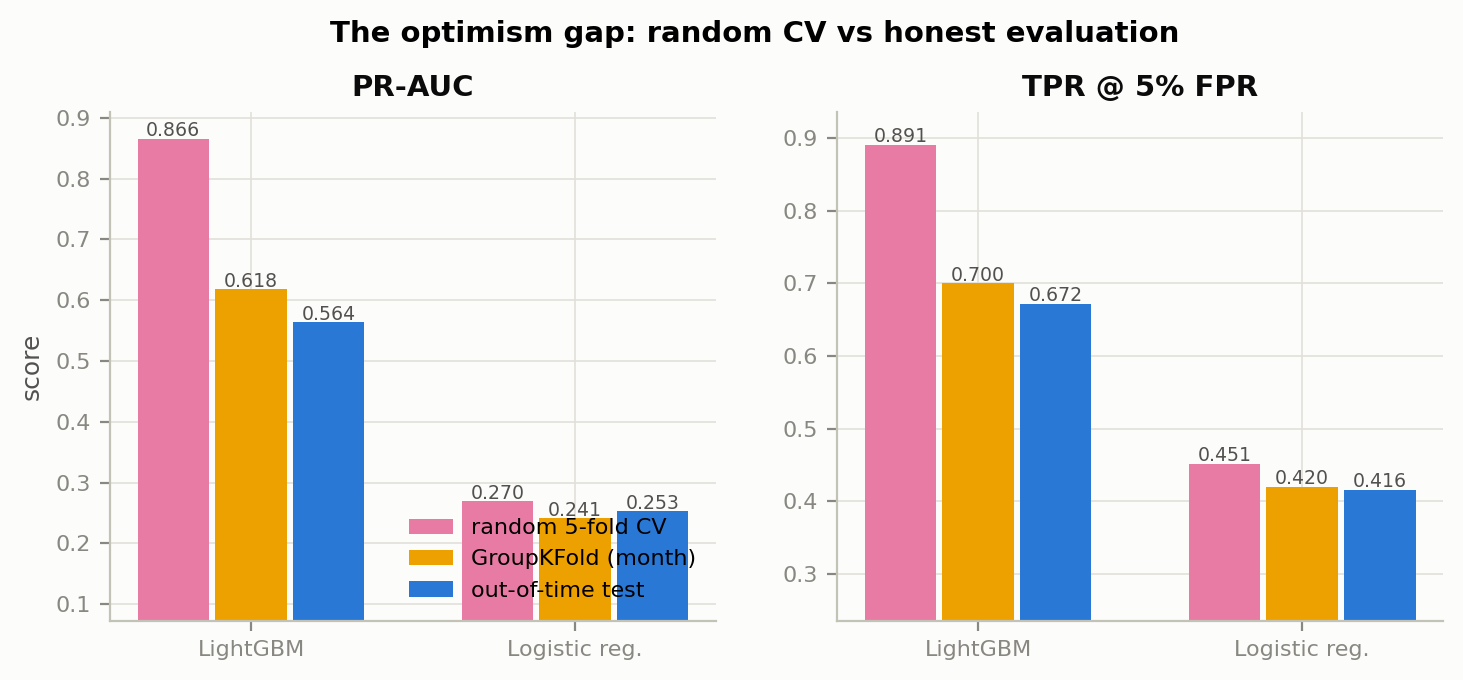

In [5]:
fig('figure_03_optimism_gap')

Random 5-fold CV reports a number that the deployed model never achieves out-of-time; the gap is the optimism a leaderboard-style evaluation silently adds.